In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset (update the path if your file is saved elsewhere)
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display the first 5 rows and basic structural info
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# 1. Check for duplicates and drop them if any exist
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)

# 2. Fix 'TotalCharges' data type
# Inspecting the data reveals blank spaces (" ") which cause it to be read as an object.
# We force conversion to numeric, which turns spaces into NaN.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Check for missing values across the dataset
print("\nMissing values per column:")
print(df.isnull().sum())

# 4. Handle missing values in TotalCharges
# Since it's a numeric continuous variable, we can fill missing values with the median.
median_total_charges = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_total_charges, inplace=True)

# 5. Drop 'customerID' as it's a unique identifier and won't help with prediction
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

print("\nData cleaning complete. Verified data types:")
print(df.dtypes)

Number of duplicate rows: 0

Missing values per column:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Data cleaning complete. Verified data types:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract  

C:\Users\vaibh\AppData\Local\Temp\ipykernel_35428\743027882.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(median_total_charges, inplace=True)


In [7]:
# Summary statistics for numerical variables
print("--- Numerical Summary Statistics ---")
display(df.describe())

# Summary statistics for categorical variables
print("\n--- Categorical Summary Statistics ---")
display(df.describe(include='O'))

# Check the distribution of our target variable: Churn
print("\n--- Churn Distribution ---")
print(df['Churn'].value_counts(normalize=True) * 100)


--- Numerical Summary Statistics ---


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000



--- Categorical Summary Statistics ---


,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174



--- Churn Distribution ---
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


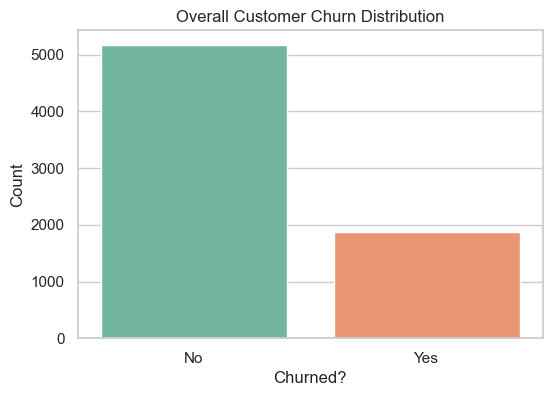

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Overall Customer Churn Distribution')
plt.xlabel('Churned?')
plt.ylabel('Count')
plt.show()

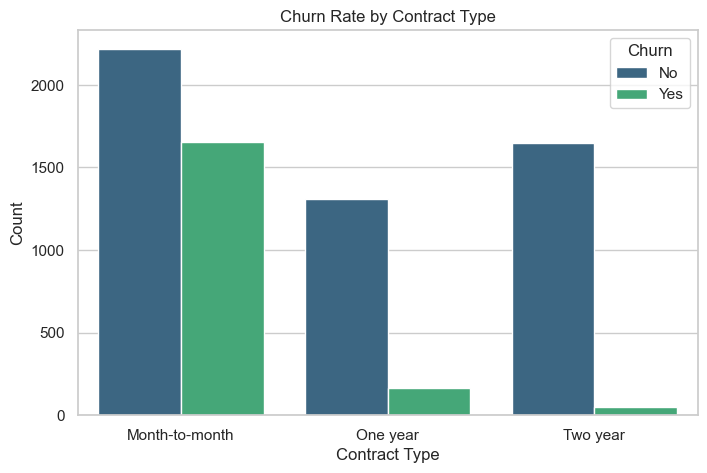

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.show()

C:\Users\vaibh\AppData\Local\Temp\ipykernel_35428\960329748.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette='pastel')
C:\Users\vaibh\AppData\Local\Temp\ipykernel_35428\960329748.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette='pastel')


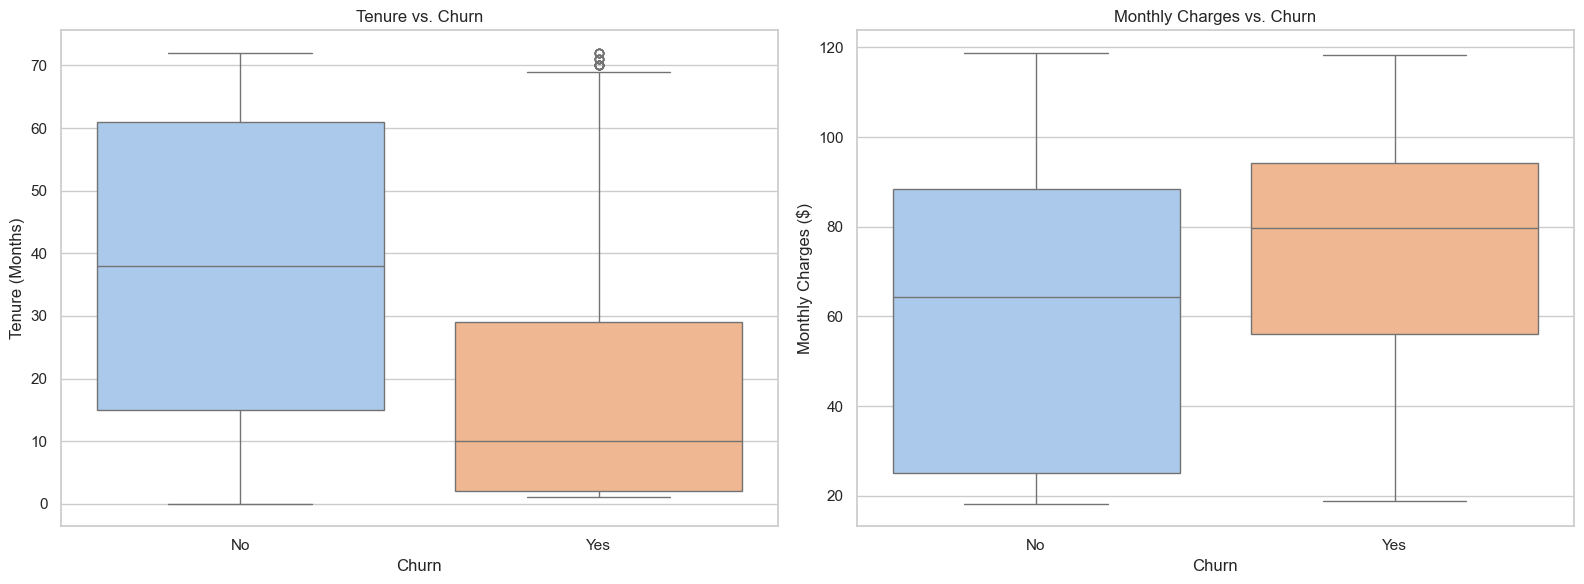

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tenure distribution based on Churn
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette='pastel')
axes[0].set_title('Tenure vs. Churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Tenure (Months)')

# Monthly Charges distribution based on Churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette='pastel')
axes[1].set_title('Monthly Charges vs. Churn')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

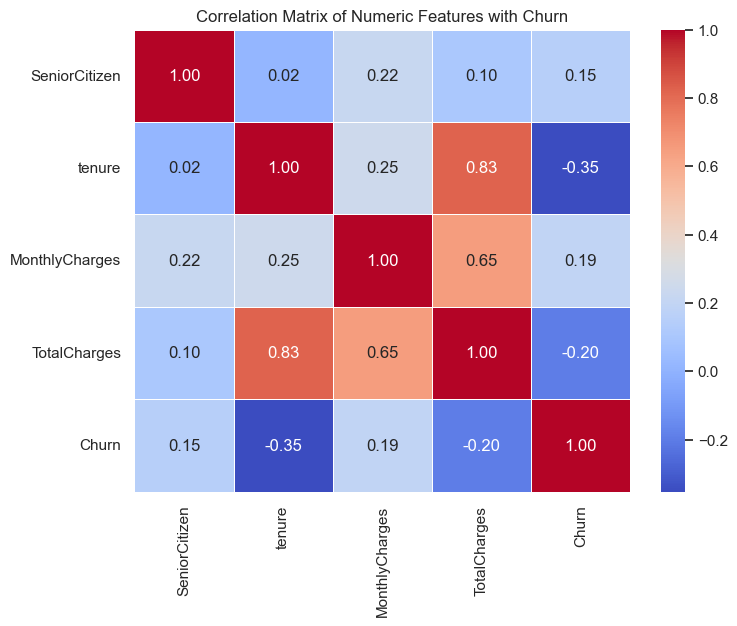

In [11]:
# Temporarily map Churn to 1 and 0 for correlation analysis
df_encoded = df.copy()
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})

# Select only numeric features
numeric_cols = df_encoded.select_dtypes(include=[np.number])

# Calculate correlation matrix
corr_matrix = numeric_cols.corr()

# Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features with Churn')
plt.show()

In [12]:
# Save the cleaned dataset to a new CSV file
df.to_csv('cleaned_telco_churn.csv', index=False)
print("Cleaned dataset successfully saved to 'cleaned_telco_churn.csv'")

Cleaned dataset successfully saved to 'cleaned_telco_churn.csv'


## 📊 Task 1: Summary of Key Findings

> **Executive Summary:** The Telco Customer Churn dataset was cleaned, audited, and analyzed. Initial exploratory data analysis reveals that customer attrition is heavily influenced by contract structure, financial billing amounts, and customer lifecycle duration (tenure). 

---

### 1. 🔍 Data Integrity & Cleaning Actions
Before analysis, several data preprocessing steps were taken to ensure data quality:
* **Missing Value Imputation:** The `TotalCharges` column contained 11 blank spaces (`" "`) for accounts with `tenure == 0`. These were converted to numeric NaN values and successfully imputed using the column **median**.
* **Feature Pruning:** The `customerID` column was dropped as it contains unique hashes that do not contribute predictive value to machine learning models.
* **Data Integrity:** No duplicate rows were detected in the dataset, leaving a clean sample size of **7,043 rows** and **20 features**.

---

### 2. 📈 Key Exploratory Insights
Our bivariate and univariate visualizations highlighted three primary drivers of customer churn:

* **The Contract Trap (Highest Risk):** Customers on **Month-to-month** contracts exhibit an alarmingly high churn rate compared to those on 1-Year or 2-Year contracts. This segment represents the primary operational risk.
* **The Critical First Year:** The distribution of `tenure` shows a massive spike in churn within the **first 0 to 12 months**. If a customer remains with the telecom operator past their first year, their probability of churning drops significantly.
* **Price Sensitivity:** Customers who churned had a noticeably higher median `MonthlyCharges` compared to loyal customers. High premium pricing without long-term contract lock-ins directly accelerates attrition.

---

### 3. 🛠️ Implications for Modeling (Next Steps)
* **Class Imbalance:** Churn represents roughly **26.5%** of the dataset, while retained customers represent **73.5%**. We will need to account for this class imbalance during model training (using stratified splits or class weighting).
* **Feature Targets:** `Contract`, `tenure`, and `MonthlyCharges` will serve as highly critical initial predictors for our classification algorithms.